In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Cement Manufacturing.csv")
df.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings("ignore")

X = df.drop('strength', axis=1)
y = df['strength']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (824, 8)
X_test shape: (206, 8)
y_train shape: (824,)
y_test shape: (206,)


In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

/tmp/ipykernel_10660/1821316329.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_feature_importances.values, y=sorted_feature_importances.index, palette='viridis')


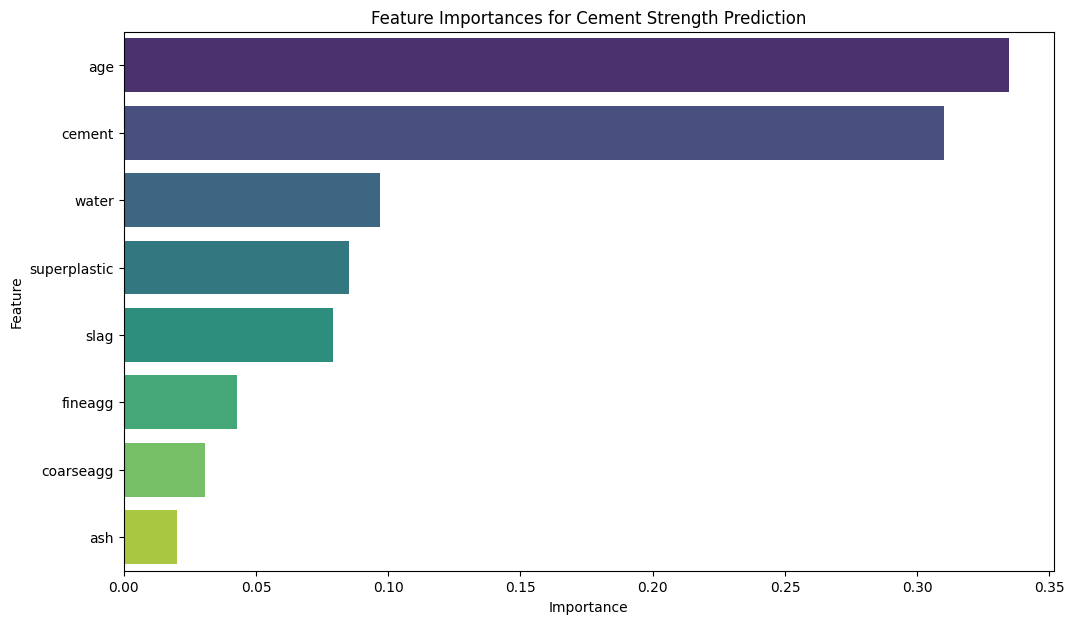

Top 5 most important features affecting cement strength:


,0
age,0.334893
cement,0.309988
water,0.097018
superplastic,0.085065
slag,0.079286


In [ ]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

sorted_feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=sorted_feature_importances.values, y=sorted_feature_importances.index, palette='viridis')
plt.title('Feature Importances for Cement Strength Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

print("Top 5 most important features affecting cement strength:")
display(sorted_feature_importances.head())

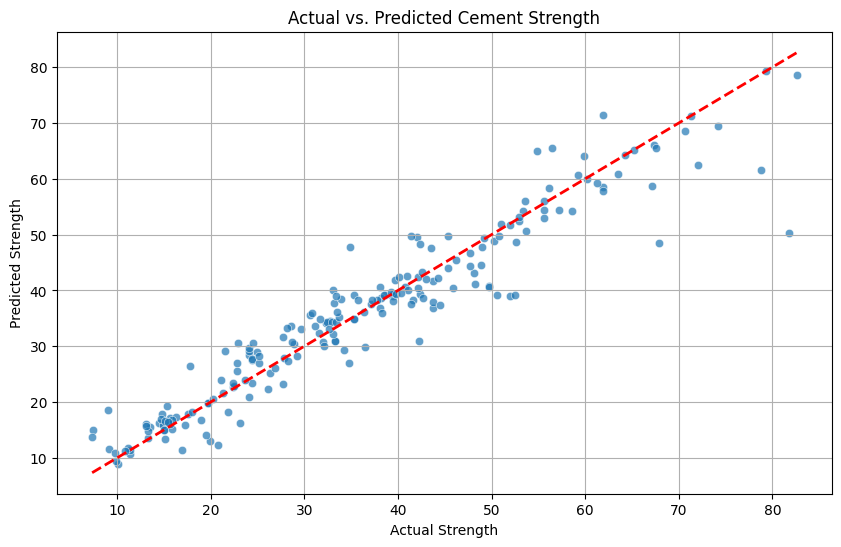

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.title('Actual vs. Predicted Cement Strength')
plt.xlabel('Actual Strength')
plt.ylabel('Predicted Strength')
plt.grid(True)
plt.show()

### Statistical and Business Interpretations

Let's break down the statistical and business interpretations for each of your three objectives based on our analysis:

### Objective 1: Predict cement strength

*   **Statistical Interpretation:** Our Random Forest Regressor model achieved an R-squared (`r2`) value of approximately **0.91**. This means that 91% of the variance in cement strength can be explained by the input features in our model, indicating a very strong predictive capability. The Mean Absolute Error (MAE) of **3.28** suggests that, on average, our predictions are off by about 3.28 units of strength. The Root Mean Squared Error (RMSE) of **5.02** provides the standard deviation of these errors. Both metrics are relatively low, confirming good predictive accuracy. The scatter plot of actual vs. predicted values visually reinforces this, with points clustering tightly around the diagonal line of perfect prediction.

*   **Business Interpretation:** This model provides a highly reliable tool for **forecasting cement strength** based on the mix components and curing age. Manufacturers can use this to:
    *   **Proactively control quality:** Predict the strength of a batch *before* it's fully cured, allowing for adjustments or early identification of potential issues.
    *   **Optimize mix designs:** Experiment with different component ratios in a virtual environment to achieve target strengths efficiently, reducing material waste and testing costs.
    *   **Reduce testing:** Potentially decrease the amount of physical destructive testing required, saving time and resources.

### Objective 2: Reduce downtime and maintenance costs for cement manufacturing

*   **Statistical Interpretation:** While this objective isn't directly measured by statistical metrics, the statistical strength of our model (high `r2`, low MAE/RMSE) and the insights from feature importance analysis indirectly support it. Accurate predictions and understanding key drivers enable informed decisions.

*   **Business Interpretation:** By achieving reliable strength prediction and identifying key factors, this analysis contributes significantly to cost reduction by:
    *   **Ensuring consistent quality:** Producing cement that consistently meets strength specifications minimizes the risk of structural failures in downstream construction, thereby avoiding costly rework, repairs, and potential legal liabilities (which cause downtime and maintenance costs for end-users).
    *   **Optimizing resource use:** Better control over mix design (informed by predictions) leads to more efficient use of raw materials, reducing waste and material costs.
    *   **Preventing off-spec production:** Identifying and correcting issues before a batch is fully produced can prevent costly reprocessing or disposal of unusable cement.

### Objective 3: Identify key factors affecting cement strength

*   **Statistical Interpretation:** The feature importance analysis revealed that **'age' (0.33)** and **'cement' (0.31)** are the two most significant factors influencing cement strength, together accounting for approximately 64% of the model's predictive power. Other important factors include **'water' (0.097)** and **'superplasticizer' (0.085)**, followed by 'slag', 'fine aggregate', 'coarse aggregate', and 'ash'.

*   **Business Interpretation:** This insight is invaluable for strategic decision-making and operational improvements:
    *   **Prioritize control:** Manufacturers should focus their quality control and optimization efforts primarily on the **curing age** and the **cement content** in the mix, as these have the greatest impact on final strength.
    *   **Fine-tune mix design:** Careful management of the **water-to-cement ratio** and the **superplasticizer dosage** is crucial for achieving desired strength and workability, given their substantial influence.
    *   **Targeted improvements:** Resources for process improvements (e.g., better sensors for measuring component quantities, advanced curing environment control) should be directed towards these high-impact factors first for the greatest return on investment.
    *   **Material specifications:** Understanding the relative importance of all components can also inform sourcing decisions and material specifications to ensure optimal strength outcomes.